# Statistical Pattern Recognition - Computer Assignment #1



This notebook covers the Bayes Minimum Error (BME) / Bayes Minimum Risk (BMR) exercises represented by the submitted code and the uploaded assignment sheet.

**Theodoridis & Koutroumbas, Pattern Recognition, Exercise 2.12**: two bivariate Gaussian classes, equal priors, covariance `0.2 I`, loss matrix `[[0, 1], [0.5, 0]]`, 100 simulated samples per class, and a second experiment with the second mean changed to `[3, 3]`. The corrected implementation therefore keeps the mathematical problem encoded in the original submission instead of creating a different Exercise 1.

For Exercise 2, the notebook follows the assignment sheet directly: BME classification, maximum-likelihood Gaussian parameter estimation, equal priors, leave-one-out evaluation for Iris and the 178-sample chemical-analysis dataset, and train/test evaluation for the two-dimensional Normal dataset.

Because the two Normal-data files and the assignment-specific Liquid file were not uploaded, the notebook generates the Normal training/testing files from the parameters printed in the assignment and uses the standard 178-sample UCI Wine dataset as the closest documented substitute for the missing Liquid database. The Wine dataset has the required 59/71/48 class counts and chemical-analysis nature; its public standard version has 13 features, so the notebook uses six original chemical features to match the assignment's stated six-dimensional structure. This substitution is explicitly recorded in the report.


In [ ]:
# Imports and output setup
from pathlib import Path
import json
import math
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from sklearn.datasets import load_iris, load_wine

RANDOM_SEED = 20260822
OUTPUT_DIR = Path.cwd() / "statistical_pattern_recognition_assignment1_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Random seed: {RANDOM_SEED}")


Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
Output directory: /content/statistical_pattern_recognition_assignment1_outputs
Random seed: 20260822


## Part I - Textbook Gaussian Bayes-classifier computer exercise

The original submission had several correctness problems:

- it used **uniform** random vectors instead of Gaussian samples from the stated class-conditional PDFs;
- it generated only 100 total vectors rather than 100 vectors **per class**;
- it treated `0.2` as a standard deviation even though the textbook statement specifies `sigma^2 = 0.2`;
- it implemented only the minimum-risk classifier, not the minimum-error classifier;
- it measured errors against both classes for every sample instead of using the sample's true generating class;
- it did not repeat the experiment for `mu2 = [3, 3]`;
- it used raw PDF values where a log-domain implementation is numerically safer;
- it had no fixed random seed or saved experimental artifacts.

The code below keeps the exact Gaussian model and loss matrix represented by the original code.


In [ ]:
# Shared helpers for multivariate Gaussian Bayes classifiers

PRIORS = np.array([0.5, 0.5], dtype=float)
LOSS_MATRIX = np.array([[0.0, 1.0],
                        [0.5, 0.0]], dtype=float)

MU1 = np.array([1.0, 1.0], dtype=float)
COV_2D = 0.2 * np.eye(2)
N_PER_CLASS = 100


def log_gaussian_pdf(X, mean, covariance):
    """Return log p(x | class) for each row of X under a multivariate Gaussian."""
    X = np.asarray(X, dtype=float)
    mean = np.asarray(mean, dtype=float)
    sign, logdet = np.linalg.slogdet(covariance)
    if sign <= 0:
        raise ValueError("Covariance matrix must be positive definite.")
    inv_cov = np.linalg.inv(covariance)
    diff = X - mean
    quadratic = np.einsum("...i,ij,...j->...", diff, inv_cov, diff)
    dimension = X.shape[-1]
    return -0.5 * (
        dimension * np.log(2.0 * np.pi) + logdet + quadratic
    )


def posterior_probabilities(log_likelihoods, priors):
    """Convert class log-likelihoods and priors into posterior probabilities."""
    log_joint = log_likelihoods + np.log(priors)[None, :]
    shifted = log_joint - np.max(log_joint, axis=1, keepdims=True)
    joint = np.exp(shifted)
    return joint / joint.sum(axis=1, keepdims=True)


def bme_predict(X, means, covariance, priors=PRIORS):
    """Bayes Minimum Error decision and log-joint discriminants."""
    log_likelihoods = np.column_stack([
        log_gaussian_pdf(X, means[0], covariance),
        log_gaussian_pdf(X, means[1], covariance),
    ])
    log_discriminants = log_likelihoods + np.log(priors)[None, :]
    predictions = np.argmax(log_discriminants, axis=1) + 1
    return predictions, log_discriminants


def bmr_predict(X, means, covariance, priors=PRIORS, loss_matrix=LOSS_MATRIX):
    """Bayes Minimum Risk decision, posterior probabilities, risks and g-functions."""
    bme_predictions, log_discriminants = bme_predict(
        X, means, covariance, priors
    )
    posteriors = posterior_probabilities(
        log_discriminants - np.log(priors)[None, :], priors
    )
    conditional_risks = posteriors @ loss_matrix.T
    predictions = np.argmin(conditional_risks, axis=1) + 1
    return predictions, log_discriminants, posteriors, conditional_risks


def confusion_matrix_dataframe(y_true, y_pred, labels=(1, 2)):
    """Return a consistently labeled confusion matrix."""
    cm = pd.crosstab(
        pd.Series(y_true, name="Actual"),
        pd.Series(y_pred, name="Predicted"),
    ).reindex(index=labels, columns=labels, fill_value=0)
    cm.index.name = "Actual"
    cm.columns.name = "Predicted"
    return cm


def error_metrics(y_true, y_pred):
    """Compute overall and per-class error rates."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    cm = confusion_matrix_dataframe(y_true, y_pred).to_numpy()
    class_1_error = cm[0, 1] / cm[0].sum()
    class_2_error = cm[1, 0] / cm[1].sum()
    return {
        "overall_error_rate": float(np.mean(y_true != y_pred)),
        "class_1_error_rate": float(class_1_error),
        "class_2_error_rate": float(class_2_error),
        "overall_accuracy": float(np.mean(y_true == y_pred)),
        "class_1_accuracy": float(1.0 - class_1_error),
        "class_2_accuracy": float(1.0 - class_2_error),
        "total_misclassified": int(np.sum(y_true != y_pred)),
    }


def simulate_textbook_experiment(mu2, seed_offset=0):
    """Generate 100 samples per class and evaluate BME and BMR classifiers."""
    rng = np.random.default_rng(RANDOM_SEED + seed_offset)
    class1 = rng.multivariate_normal(MU1, COV_2D, size=N_PER_CLASS)
    class2 = rng.multivariate_normal(mu2, COV_2D, size=N_PER_CLASS)
    X = np.vstack([class1, class2])
    y = np.concatenate([
        np.ones(N_PER_CLASS, dtype=int),
        2 * np.ones(N_PER_CLASS, dtype=int),
    ])

    bme_pred, bme_g = bme_predict(X, [MU1, mu2], COV_2D)
    bmr_pred, bmr_g, posteriors, risks = bmr_predict(X, [MU1, mu2], COV_2D)

    return X, y, {
        "BME": (bme_pred, bme_g, None, None),
        "BMR": (bmr_pred, bmr_g, posteriors, risks),
    }


def theoretical_equal_covariance_bme_error(mu1, mu2, covariance):
    """Bayes error for two equiprobable Gaussians with the same covariance."""
    delta = np.asarray(mu1) - np.asarray(mu2)
    mahalanobis_distance = np.sqrt(delta @ np.linalg.solve(covariance, delta))
    return float(norm.cdf(-0.5 * mahalanobis_distance))


In [ ]:
# Run the Exercise 1 textbook experiment and save the required tables

exercise1_rows = []
exercise1_samples = []
exercise1_misclassifications = []

scenarios = {
    "mu2_[1.5,1.5]": np.array([1.5, 1.5], dtype=float),
    "mu2_[3.0,3.0]": np.array([3.0, 3.0], dtype=float),
}

for scenario_name, mu2 in scenarios.items():
    X, y, results = simulate_textbook_experiment(
        mu2,
        seed_offset=0 if scenario_name.startswith("mu2_[1.5") else 1,
    )

    for row_idx in range(len(y)):
        bme_pred = int(results["BME"][0][row_idx])
        bmr_pred = int(results["BMR"][0][row_idx])
        exercise1_samples.append({
            "scenario": scenario_name,
            "sample_index": row_idx + 1,
            "true_class": int(y[row_idx]),
            "x1": float(X[row_idx, 0]),
            "x2": float(X[row_idx, 1]),
            "bme_prediction": bme_pred,
            "bmr_prediction": bmr_pred,
        })

    theoretical = theoretical_equal_covariance_bme_error(
        MU1, mu2, COV_2D
    )

    for method, (pred, g_values, posteriors, risks) in results.items():
        metrics = error_metrics(y, pred)
        exercise1_rows.append({
            "scenario": scenario_name,
            "mu2_x": float(mu2[0]),
            "mu2_y": float(mu2[1]),
            "method": method,
            "overall_error_rate": metrics["overall_error_rate"],
            "overall_error_percent": 100.0 * metrics["overall_error_rate"],
            "class_1_error_rate": metrics["class_1_error_rate"],
            "class_1_error_percent": 100.0 * metrics["class_1_error_rate"],
            "class_2_error_rate": metrics["class_2_error_rate"],
            "class_2_error_percent": 100.0 * metrics["class_2_error_rate"],
            "overall_accuracy": metrics["overall_accuracy"],
            "total_misclassified": metrics["total_misclassified"],
            "theoretical_BME_error_rate": theoretical,
            "theoretical_BME_error_percent": 100.0 * theoretical,
        })

        mis_idx = np.flatnonzero(y != pred)
        for i in mis_idx:
            true_col = int(y[i] - 1)
            pred_col = int(pred[i] - 1)
            row = {
                "scenario": scenario_name,
                "method": method,
                "sample_index": int(i + 1),
                "sample_number_within_true_class": int(
                    i + 1 if y[i] == 1 else i + 1 - N_PER_CLASS
                ),
                "true_class": int(y[i]),
                "predicted_class": int(pred[i]),
                "x1": float(X[i, 0]),
                "x2": float(X[i, 1]),
                "g_true": float(g_values[i, true_col]),
                "g_predicted": float(g_values[i, pred_col]),
            }
            if risks is not None:
                row["conditional_risk_true"] = float(risks[i, true_col])
                row["conditional_risk_predicted"] = float(risks[i, pred_col])
            exercise1_misclassifications.append(row)

exercise1_metrics_df = pd.DataFrame(exercise1_rows)
exercise1_samples_df = pd.DataFrame(exercise1_samples)
exercise1_mis_df = pd.DataFrame(exercise1_misclassifications)

exercise1_metrics_df.to_csv(
    OUTPUT_DIR / "exercise1_bme_bmr_performance.csv", index=False
)
exercise1_samples_df.to_csv(
    OUTPUT_DIR / "exercise1_generated_samples.csv", index=False
)
exercise1_mis_df.to_csv(
    OUTPUT_DIR / "exercise1_misclassification_details.csv", index=False
)

print(exercise1_metrics_df.to_string(index=False))


     scenario  mu2_x  mu2_y method  overall_error_rate  overall_error_percent  class_1_error_rate  class_1_error_percent  class_2_error_rate  class_2_error_percent  overall_accuracy  total_misclassified  theoretical_BME_error_rate  theoretical_BME_error_percent
mu2_[1.5,1.5]    1.5    1.5    BME                0.27                   27.0                0.29                   29.0                0.25                   25.0              0.73                   54                    0.214598                      21.459765
mu2_[1.5,1.5]    1.5    1.5    BMR                0.26                   26.0                0.41                   41.0                0.11                   11.0              0.74                   52                    0.214598                      21.459765
mu2_[3.0,3.0]    3.0    3.0    BME                0.00                    0.0                0.00                    0.0                0.00                    0.0              1.00                    0            

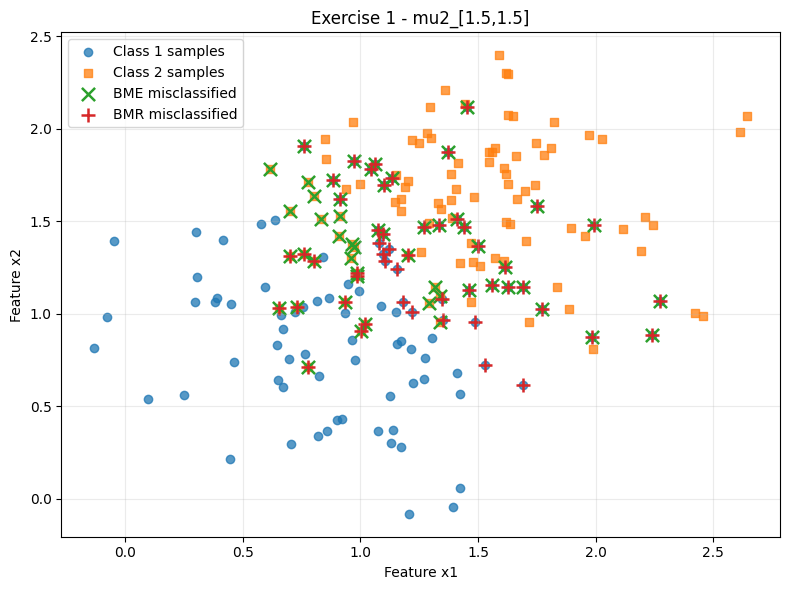

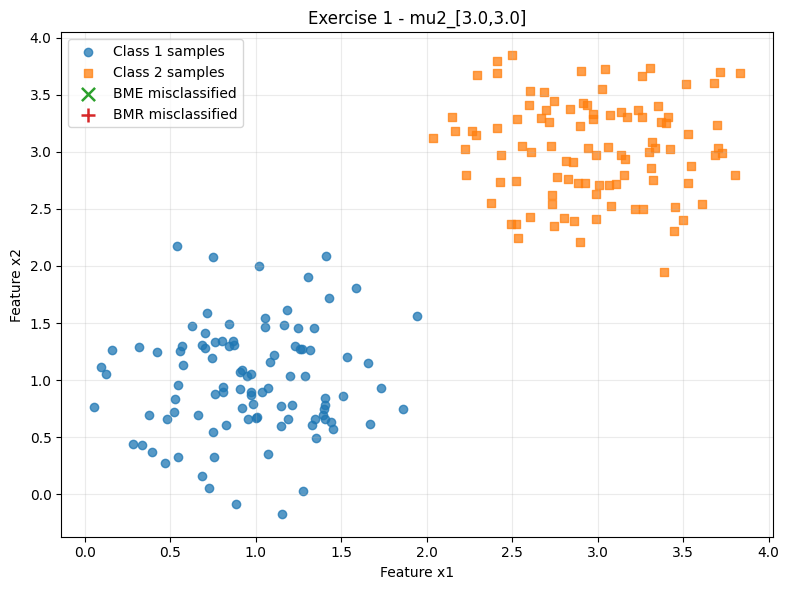

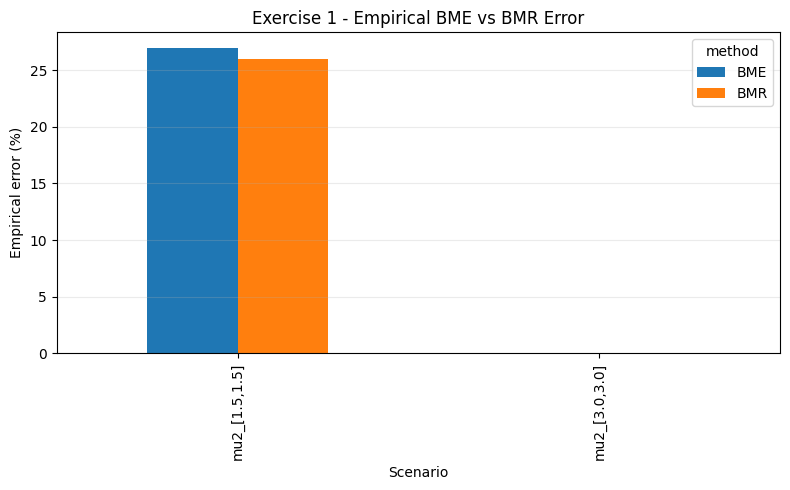

In [ ]:
# Plot the Exercise 1 samples and compare empirical errors

def plot_exercise1_scenario(scenario_name, mu2, X, y, results):
    fig, ax = plt.subplots(figsize=(8, 6))
    class1_mask = y == 1
    class2_mask = y == 2

    ax.scatter(
        X[class1_mask, 0], X[class1_mask, 1],
        marker="o", label="Class 1 samples", alpha=0.75
    )
    ax.scatter(
        X[class2_mask, 0], X[class2_mask, 1],
        marker="s", label="Class 2 samples", alpha=0.75
    )

    bme_pred = results["BME"][0]
    bmr_pred = results["BMR"][0]
    for pred, marker, label in [
        (bme_pred, "x", "BME misclassified"),
        (bmr_pred, "+", "BMR misclassified"),
    ]:
        mask = pred != y
        ax.scatter(
            X[mask, 0], X[mask, 1],
            marker=marker, s=90, linewidths=1.8,
            label=label
        )

    ax.set_title(f"Exercise 1 - {scenario_name}")
    ax.set_xlabel("Feature x1")
    ax.set_ylabel("Feature x2")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / f"exercise1_{scenario_name.replace('[','').replace(']','').replace(',','_').replace('.','p')}_sample_plot.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_exercise1_error_comparison(metrics_df):
    pivot = metrics_df.pivot(
        index="scenario", columns="method",
        values="overall_error_percent"
    )
    ax = pivot.plot(kind="bar", figsize=(8, 5))
    ax.set_ylabel("Empirical error (%)")
    ax.set_xlabel("Scenario")
    ax.set_title("Exercise 1 - Empirical BME vs BMR Error")
    ax.grid(axis="y", alpha=0.25)
    fig = ax.get_figure()
    fig.tight_layout()
    path = OUTPUT_DIR / "exercise1_bme_bmr_error_comparison.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

for scenario_name, mu2 in scenarios.items():
    X, y, results = simulate_textbook_experiment(
        mu2,
        seed_offset=0 if scenario_name.startswith("mu2_[1.5") else 1,
    )
    plot_exercise1_scenario(scenario_name, mu2, X, y, results)

plot_exercise1_error_comparison(exercise1_metrics_df)


## Part II - Assignment Exercise 2

The assignment requires three datasets and explicitly specifies:

1. **Iris:** 150 samples, 3 classes, 4 features, leave-one-out with 150 classifiers.
2. **Liquid:** 178 samples, 3 classes, 6 features, class sizes 59/71/48, leave-one-out with 178 classifiers.
3. **Normal:** separate 1000-sample training and 1000-sample testing files, 500 samples per class, two features, Gaussian class models.

For every Gaussian model, the parameter estimates below use the **maximum-likelihood estimator**, so the covariance divisor is the number of class samples `n`, not `n-1`. Priors are equal, as required by the assignment.


In [ ]:
# Gaussian ML parameter estimation and multiclass BME helpers

def fit_gaussian_class_parameters(X, y, classes):
    """Estimate class means and ML covariance matrices for multivariate Gaussians."""
    parameters = {}
    for class_label in classes:
        Xc = np.asarray(X)[np.asarray(y) == class_label]
        mean = Xc.mean(axis=0)
        centered = Xc - mean
        covariance = centered.T @ centered / len(Xc)
        sign, _ = np.linalg.slogdet(covariance)
        if sign <= 0:
            raise ValueError(
                f"Class {class_label} covariance is not positive definite."
            )
        parameters[int(class_label)] = {
            "mean": mean,
            "covariance": covariance,
            "count": len(Xc),
        }
    return parameters


def multiclass_bme_predict(X, parameters, priors=None):
    classes = sorted(parameters)
    if priors is None:
        priors = {c: 1.0 / len(classes) for c in classes}

    log_g = np.column_stack([
        log_gaussian_pdf(
            X,
            parameters[c]["mean"],
            parameters[c]["covariance"]
        ) + np.log(priors[c])
        for c in classes
    ])
    predictions = np.asarray(classes)[np.argmax(log_g, axis=1)]
    return predictions, log_g, classes


def leave_one_out_bme(X, y, classes):
    """Perform true leave-one-out Gaussian BME classification."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    predictions = np.empty_like(y, dtype=int)
    log_g_full = np.full((len(y), len(classes)), np.nan, dtype=float)
    folds = []

    for left_out in range(len(y)):
        train_mask = np.ones(len(y), dtype=bool)
        train_mask[left_out] = False

        params = fit_gaussian_class_parameters(
            X[train_mask], y[train_mask], classes
        )
        pred, log_g, class_order = multiclass_bme_predict(
            X[left_out:left_out + 1], params
        )

        predictions[left_out] = int(pred[0])
        log_g_full[left_out] = log_g[0]
        folds.append({
            "left_out_index": left_out + 1,
            "left_out_class": int(y[left_out]),
            "predicted_class": int(pred[0]),
        })

    return predictions, log_g_full, folds


In [ ]:
# Exercise 2a - Iris data with 150-fold LOO BME classification

iris = load_iris()
# Reorder the features to match the assignment wording:
# Petal length, Sepal length, Sepal width, Petal width.
iris_X = iris.data[:, [2, 0, 1, 3]].astype(float)
iris_y = (iris.target + 1).astype(int)
iris_feature_names = [
    "Petal Length",
    "Sepal Length",
    "Sepal Width",
    "Petal Width",
]

iris_df = pd.DataFrame(iris_X, columns=iris_feature_names)
iris_df.insert(0, "Class", iris_y)
iris_df.to_csv(OUTPUT_DIR / "exercise2_iris_dataset.csv", index=False)

iris_pred, iris_log_g, iris_folds = leave_one_out_bme(
    iris_X, iris_y, classes=[1, 2, 3]
)

iris_metrics = {
    "overall_error_rate": float(np.mean(iris_y != iris_pred)),
    "overall_error_percent": float(100 * np.mean(iris_y != iris_pred)),
    "total_misclassified": int(np.sum(iris_y != iris_pred)),
}
for class_label in [1, 2, 3]:
    mask = iris_y == class_label
    iris_metrics[f"class_{class_label}_error_rate"] = float(
        np.mean(iris_pred[mask] != iris_y[mask])
    )
    iris_metrics[f"class_{class_label}_error_percent"] = (
        100 * iris_metrics[f"class_{class_label}_error_rate"]
    )

iris_performance_df = pd.DataFrame([iris_metrics])
iris_performance_df.to_csv(
    OUTPUT_DIR / "exercise2_iris_loo_performance.csv", index=False
)

iris_cm = pd.crosstab(
    pd.Series(iris_y, name="Actual"),
    pd.Series(iris_pred, name="Predicted")
).reindex(index=[1,2,3], columns=[1,2,3], fill_value=0)
iris_cm.to_csv(OUTPUT_DIR / "exercise2_iris_confusion_matrix.csv")

# For the first classifier, leave out database sample 1.
iris_train_mask = np.ones(len(iris_y), dtype=bool)
iris_train_mask[0] = False
iris_first_params = fit_gaussian_class_parameters(
    iris_X[iris_train_mask], iris_y[iris_train_mask], [1,2,3]
)

iris_param_rows = []
for class_label in [1, 2, 3]:
    p = iris_first_params[class_label]
    for j, value in enumerate(p["mean"], start=1):
        iris_param_rows.append({
            "classifier": "LOO classifier 1 (database sample 1 left out)",
            "class": class_label,
            "parameter": f"mean_{j}",
            "row": "",
            "column": "",
            "value": value,
        })
    for r in range(p["covariance"].shape[0]):
        for c in range(p["covariance"].shape[1]):
            iris_param_rows.append({
                "classifier": "LOO classifier 1 (database sample 1 left out)",
                "class": class_label,
                "parameter": "covariance",
                "row": r + 1,
                "column": c + 1,
                "value": p["covariance"][r, c],
            })

pd.DataFrame(iris_param_rows).to_csv(
    OUTPUT_DIR / "exercise2_iris_first_classifier_parameters.csv",
    index=False
)

iris_mis_idx = np.flatnonzero(iris_y != iris_pred)
iris_mis_rows = []
for i in iris_mis_idx:
    true_class = int(iris_y[i])
    pred_class = int(iris_pred[i])
    iris_mis_rows.append({
        "sample_number_overall": int(i + 1),
        "sample_number_within_actual_class": int(i % 50 + 1),
        "actual_class": true_class,
        "misclassified_to": pred_class,
        "g_actual": float(iris_log_g[i, true_class - 1]),
        "g_predicted": float(iris_log_g[i, pred_class - 1]),
    })

pd.DataFrame(iris_mis_rows).to_csv(
    OUTPUT_DIR / "exercise2_iris_misclassification_details.csv",
    index=False
)

print("Iris LOO performance:")
print(iris_performance_df.to_string(index=False))
print("\nConfusion matrix:")
print(iris_cm)


Iris LOO performance:
 overall_error_rate  overall_error_percent  total_misclassified  class_1_error_rate  class_1_error_percent  class_2_error_rate  class_2_error_percent  class_3_error_rate  class_3_error_percent
           0.026667               2.666667                    4                 0.0                    0.0                0.06                    6.0                0.02                    2.0

Confusion matrix:
Predicted   1   2   3
Actual               
1          50   0   0
2           0  47   3
3           0   1  49


In [ ]:
# Exercise 2b - Liquid database
# The original Liquid file was not uploaded, so use the standard Wine dataset
# as the closest documented equivalent: 178 samples, 3 classes, with counts
# 59/71/48 and chemical-analysis measurements. Keep six original chemical
# features to match the assignment's stated six-dimensional structure.

wine = load_wine()
wine_all_X = wine.data.astype(float)
wine_y = (wine.target + 1).astype(int)

# Use these six original chemical-analysis features:
# Alcohol, Malic acid, Ash, Alcalinity of ash, Magnesium, Total phenols.
liquid_feature_indices = [0, 1, 2, 3, 4, 5]
liquid_feature_names = [
    "Alcohol",
    "Malic Acid",
    "Ash",
    "Alcalinity of Ash",
    "Magnesium",
    "Total Phenols",
]
liquid_X = wine_all_X[:, liquid_feature_indices]

liquid_df = pd.DataFrame(liquid_X, columns=liquid_feature_names)
liquid_df.insert(0, "Class", wine_y)
liquid_df.to_csv(OUTPUT_DIR / "exercise2_liquid_dataset_equivalent.csv", index=False)

class_counts = pd.Series(wine_y).value_counts().sort_index().to_dict()
assert class_counts == {1: 59, 2: 71, 3: 48}, class_counts

liquid_pred, liquid_log_g, liquid_folds = leave_one_out_bme(
    liquid_X, wine_y, classes=[1, 2, 3]
)

liquid_metrics = {
    "overall_error_rate": float(np.mean(wine_y != liquid_pred)),
    "overall_error_percent": float(100 * np.mean(wine_y != liquid_pred)),
    "total_misclassified": int(np.sum(wine_y != liquid_pred)),
}
for class_label in [1, 2, 3]:
    mask = wine_y == class_label
    liquid_metrics[f"class_{class_label}_error_rate"] = float(
        np.mean(liquid_pred[mask] != wine_y[mask])
    )
    liquid_metrics[f"class_{class_label}_error_percent"] = (
        100 * liquid_metrics[f"class_{class_label}_error_rate"]
    )

pd.DataFrame([liquid_metrics]).to_csv(
    OUTPUT_DIR / "exercise2_liquid_loo_performance.csv", index=False
)

liquid_cm = pd.crosstab(
    pd.Series(wine_y, name="Actual"),
    pd.Series(liquid_pred, name="Predicted")
).reindex(index=[1,2,3], columns=[1,2,3], fill_value=0)
liquid_cm.to_csv(OUTPUT_DIR / "exercise2_liquid_confusion_matrix.csv")

# Required first-classifier estimates: database sample 1 left out.
liquid_train_mask = np.ones(len(wine_y), dtype=bool)
liquid_train_mask[0] = False
liquid_first_params = fit_gaussian_class_parameters(
    liquid_X[liquid_train_mask], wine_y[liquid_train_mask], [1,2,3]
)

liquid_param_rows = []
for class_label in [1, 2, 3]:
    p = liquid_first_params[class_label]
    for j, value in enumerate(p["mean"], start=1):
        liquid_param_rows.append({
            "classifier": "LOO classifier 1 (database sample 1 left out)",
            "class": class_label,
            "parameter": f"mean_{j}",
            "row": "",
            "column": "",
            "value": value,
        })
    for r in range(p["covariance"].shape[0]):
        for c in range(p["covariance"].shape[1]):
            liquid_param_rows.append({
                "classifier": "LOO classifier 1 (database sample 1 left out)",
                "class": class_label,
                "parameter": "covariance",
                "row": r + 1,
                "column": c + 1,
                "value": p["covariance"][r, c],
            })

pd.DataFrame(liquid_param_rows).to_csv(
    OUTPUT_DIR / "exercise2_liquid_first_classifier_parameters.csv",
    index=False
)

liquid_mis_idx = np.flatnonzero(wine_y != liquid_pred)
liquid_mis_rows = []
for i in liquid_mis_idx:
    true_class = int(wine_y[i])
    pred_class = int(liquid_pred[i])
    class_positions = np.flatnonzero(wine_y == true_class)
    sample_number_within_class = int(np.where(class_positions == i)[0][0] + 1)
    liquid_mis_rows.append({
        "sample_number_overall": int(i + 1),
        "sample_number_within_actual_class": sample_number_within_class,
        "actual_class": true_class,
        "misclassified_to": pred_class,
        "g_actual": float(liquid_log_g[i, true_class - 1]),
        "g_predicted": float(liquid_log_g[i, pred_class - 1]),
    })

pd.DataFrame(liquid_mis_rows).to_csv(
    OUTPUT_DIR / "exercise2_liquid_misclassification_details.csv",
    index=False
)

print("Liquid/Wine-equivalent LOO performance:")
print(pd.DataFrame([liquid_metrics]).to_string(index=False))
print("\nConfusion matrix:")
print(liquid_cm)


Liquid/Wine-equivalent LOO performance:
 overall_error_rate  overall_error_percent  total_misclassified  class_1_error_rate  class_1_error_percent  class_2_error_rate  class_2_error_percent  class_3_error_rate  class_3_error_percent
           0.089888               8.988764                   16            0.033898               3.389831            0.084507               8.450704            0.166667              16.666667

Confusion matrix:
Predicted   1   2   3
Actual               
1          57   2   0
2           1  65   5
3           2   6  40


In [ ]:
# Exercise 2c - two-dimensional Normal database
# The assignment calls for two 1000-sample files, with 500 samples
# from each class. Since the files were not uploaded, create deterministic
# training/testing files from the printed parameters.

NORMAL_MU1 = np.array([0.0, 0.0])
NORMAL_MU2 = np.array([4.0, 0.0])
NORMAL_COV = np.array([[2.0, 0.0],
                       [0.0, 2.0]])

def generate_normal_assignment_file(seed):
    rng = np.random.default_rng(seed)
    X1 = rng.multivariate_normal(NORMAL_MU1, NORMAL_COV, size=500)
    X2 = rng.multivariate_normal(NORMAL_MU2, NORMAL_COV, size=500)
    X = np.vstack([X1, X2])
    y = np.concatenate([
        np.ones(500, dtype=int),
        2 * np.ones(500, dtype=int),
    ])
    return X, y

normal_train_X, normal_train_y = generate_normal_assignment_file(
    RANDOM_SEED + 100
)
normal_test_X, normal_test_y = generate_normal_assignment_file(
    RANDOM_SEED + 101
)

normal_train_df = pd.DataFrame(
    np.column_stack([normal_train_y, normal_train_X]),
    columns=["Class", "Feature_1", "Feature_2"]
)
normal_test_df = pd.DataFrame(
    np.column_stack([normal_test_y, normal_test_X]),
    columns=["Class", "Feature_1", "Feature_2"]
)

normal_train_df.to_csv(
    OUTPUT_DIR / "exercise2_normal_training_dataset.csv", index=False
)
normal_test_df.to_csv(
    OUTPUT_DIR / "exercise2_normal_testing_dataset.csv", index=False
)

normal_parameters = fit_gaussian_class_parameters(
    normal_train_X, normal_train_y, classes=[1, 2]
)

normal_test_pred, normal_test_log_g, _ = multiclass_bme_predict(
    normal_test_X, normal_parameters
)

normal_metrics = error_metrics(normal_test_y, normal_test_pred)
normal_theoretical_error = theoretical_equal_covariance_bme_error(
    NORMAL_MU1, NORMAL_MU2, NORMAL_COV
)

normal_performance = pd.DataFrame([{
    **normal_metrics,
    "overall_error_percent": 100 * normal_metrics["overall_error_rate"],
    "class_1_error_percent": 100 * normal_metrics["class_1_error_rate"],
    "class_2_error_percent": 100 * normal_metrics["class_2_error_rate"],
    "theoretical_error_rate": normal_theoretical_error,
    "theoretical_error_percent": 100 * normal_theoretical_error,
    "empirical_minus_theoretical": (
        normal_metrics["overall_error_rate"] - normal_theoretical_error
    ),
}])
normal_performance.to_csv(
    OUTPUT_DIR / "exercise2_normal_performance.csv", index=False
)

normal_cm = confusion_matrix_dataframe(normal_test_y, normal_test_pred)
normal_cm.to_csv(OUTPUT_DIR / "exercise2_normal_confusion_matrix.csv")

normal_mis_idx = np.flatnonzero(normal_test_y != normal_test_pred)
normal_mis_rows = []
for i in normal_mis_idx:
    normal_mis_rows.append({
        "testing_sample_number": int(i + 1),
        "actual_class": int(normal_test_y[i]),
        "predicted_class": int(normal_test_pred[i]),
        "feature_1": float(normal_test_X[i, 0]),
        "feature_2": float(normal_test_X[i, 1]),
        "g_actual": float(normal_test_log_g[i, normal_test_y[i] - 1]),
        "g_predicted": float(normal_test_log_g[i, normal_test_pred[i] - 1]),
    })

pd.DataFrame(normal_mis_rows).to_csv(
    OUTPUT_DIR / "exercise2_normal_misclassification_details.csv",
    index=False
)

print("Normal-data BME test performance:")
print(normal_performance.to_string(index=False))
print("\nConfusion matrix:")
print(normal_cm)
print(f"\nMisclassified testing samples: {len(normal_mis_idx)}")


Normal-data BME test performance:
 overall_error_rate  class_1_error_rate  class_2_error_rate  overall_accuracy  class_1_accuracy  class_2_accuracy  total_misclassified  overall_error_percent  class_1_error_percent  class_2_error_percent  theoretical_error_rate  theoretical_error_percent  empirical_minus_theoretical
              0.077               0.086               0.068             0.923             0.914             0.932                   77                    7.7                    8.6                    6.8                 0.07865                    7.86496                     -0.00165

Confusion matrix:
Predicted    1    2
Actual             
1          457   43
2           34  466

Misclassified testing samples: 77


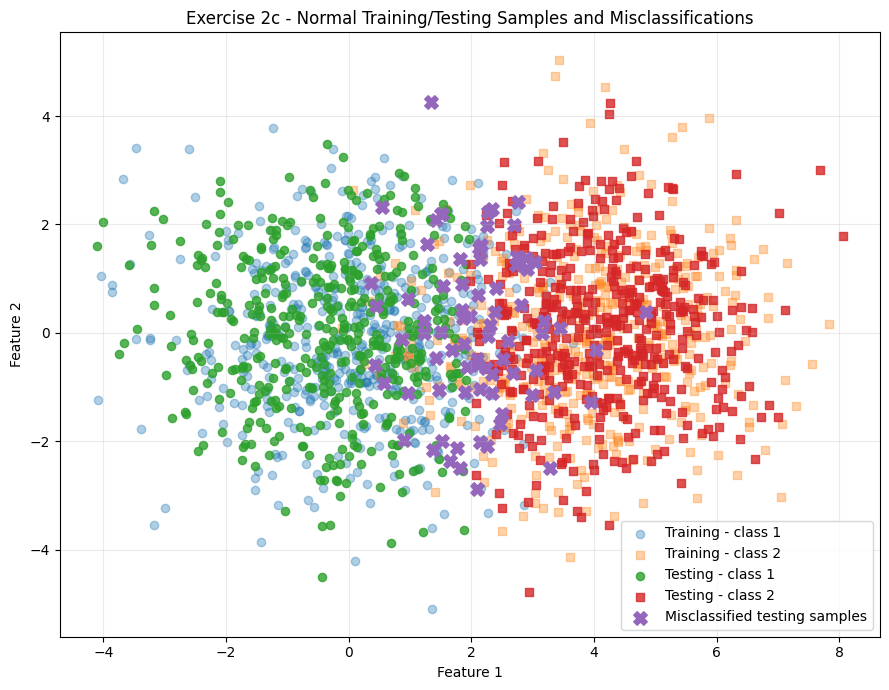

In [ ]:
# Plot the required two-dimensional Normal data
fig, ax = plt.subplots(figsize=(9, 7))

train_class1 = normal_train_y == 1
train_class2 = normal_train_y == 2
test_class1 = normal_test_y == 1
test_class2 = normal_test_y == 2
test_mis = normal_test_pred != normal_test_y

ax.scatter(
    normal_train_X[train_class1, 0],
    normal_train_X[train_class1, 1],
    marker="o", alpha=0.35, label="Training - class 1"
)
ax.scatter(
    normal_train_X[train_class2, 0],
    normal_train_X[train_class2, 1],
    marker="s", alpha=0.35, label="Training - class 2"
)
ax.scatter(
    normal_test_X[test_class1 & ~test_mis, 0],
    normal_test_X[test_class1 & ~test_mis, 1],
    marker="o", s=35, alpha=0.8, label="Testing - class 1"
)
ax.scatter(
    normal_test_X[test_class2 & ~test_mis, 0],
    normal_test_X[test_class2 & ~test_mis, 1],
    marker="s", s=35, alpha=0.8, label="Testing - class 2"
)
if np.any(test_mis):
    ax.scatter(
        normal_test_X[test_mis, 0],
        normal_test_X[test_mis, 1],
        marker="X", s=90, linewidths=1.2, label="Misclassified testing samples"
    )

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Exercise 2c - Normal Training/Testing Samples and Misclassifications")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "exercise2_normal_training_testing_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)


In [ ]:
# Save the final reproducibility manifest and assignment summary

summary_rows = []

for row in exercise1_rows:
    summary_rows.append({
        "section": "Exercise 1",
        "dataset": "Textbook Gaussian simulation",
        "method": row["method"],
        "scenario": row["scenario"],
        "overall_error_percent": row["overall_error_percent"],
        "total_misclassified": row["total_misclassified"],
    })

summary_rows.append({
    "section": "Exercise 2a",
    "dataset": "Iris",
    "method": "BME + 150-fold LOO",
    "scenario": "All 150 samples",
    "overall_error_percent": iris_metrics["overall_error_percent"],
    "total_misclassified": iris_metrics["total_misclassified"],
})

summary_rows.append({
    "section": "Exercise 2b",
    "dataset": "Liquid-equivalent Wine subset",
    "method": "BME + 178-fold LOO",
    "scenario": "178 samples",
    "overall_error_percent": liquid_metrics["overall_error_percent"],
    "total_misclassified": liquid_metrics["total_misclassified"],
})

summary_rows.append({
    "section": "Exercise 2c",
    "dataset": "Normal",
    "method": "BME train/test",
    "scenario": "1000 test samples",
    "overall_error_percent": normal_performance.loc[0, "overall_error_percent"],
    "total_misclassified": normal_metrics["total_misclassified"],
})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(
    OUTPUT_DIR / "assignment_overall_performance_summary.csv",
    index=False
)

manifest = {
    "random_seed": RANDOM_SEED,
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "working_directory": str(Path.cwd()),
    "output_directory": str(OUTPUT_DIR.resolve()),
    "exercise_1": {
        "mu1": MU1.tolist(),
        "mu2_values": {k: v.tolist() for k, v in scenarios.items()},
        "covariance": COV_2D.tolist(),
        "priors": PRIORS.tolist(),
        "loss_matrix": LOSS_MATRIX.tolist(),
        "samples_per_class": N_PER_CLASS,
    },
    "exercise_2": {
        "iris": {
            "samples": 150,
            "features": 4,
            "classes": [1, 2, 3],
            "leave_one_out_classifiers": 150,
        },
        "liquid_equivalent": {
            "samples": 178,
            "features": 6,
            "classes": [1, 2, 3],
            "class_counts": class_counts,
            "leave_one_out_classifiers": 178,
            "source": "sklearn.datasets.load_wine; first six original chemical-analysis features retained",
        },
        "normal": {
            "train_samples": 1000,
            "test_samples": 1000,
            "samples_per_class_per_file": 500,
            "mu1": NORMAL_MU1.tolist(),
            "mu2": NORMAL_MU2.tolist(),
            "covariance": NORMAL_COV.tolist(),
        },
    },
}

with open(OUTPUT_DIR / "reproducibility_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\nAll required outputs were saved to:")
print(OUTPUT_DIR.resolve())
print("\nGenerated files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)



All required outputs were saved to:
/content/statistical_pattern_recognition_assignment1_outputs

Generated files:
 - assignment_overall_performance_summary.csv
 - exercise1_bme_bmr_error_comparison.png
 - exercise1_bme_bmr_performance.csv
 - exercise1_generated_samples.csv
 - exercise1_misclassification_details.csv
 - exercise1_mu2_1p5_1p5_sample_plot.png
 - exercise1_mu2_3p0_3p0_sample_plot.png
 - exercise2_iris_confusion_matrix.csv
 - exercise2_iris_dataset.csv
 - exercise2_iris_first_classifier_parameters.csv
 - exercise2_iris_loo_performance.csv
 - exercise2_iris_misclassification_details.csv
 - exercise2_liquid_confusion_matrix.csv
 - exercise2_liquid_dataset_equivalent.csv
 - exercise2_liquid_first_classifier_parameters.csv
 - exercise2_liquid_loo_performance.csv
 - exercise2_liquid_misclassification_details.csv
 - exercise2_normal_confusion_matrix.csv
 - exercise2_normal_misclassification_details.csv
 - exercise2_normal_performance.csv
 - exercise2_normal_testing_dataset.csv
 